# Experiment 01 - Basic properties and boundary equilibria

Paper sections reproduced: Section 2, Theorem 2.1, Theorem 2.2, Theorem 2.4, Theorem 2.8.

This notebook uses Monod response functions `f_i(u)=a_i u/(b_i+u)`, which satisfy the assumptions in the paper: `f_i(0)=0` and `f_i'(u)>0`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

def monod(u, a, b):
    return a * u / (b + u)

def monod_inv(D, a, b):
    if not (0 < D < a):
        raise ValueError("Need 0 < D < a for positive inverse.")
    return b * D / (a - D)

def rhs(t, U, p):
    S, x, y, z = U
    f1 = monod(S, p["a1"], p["b1"])
    f2 = monod(x, p["a2"], p["b2"])
    f3 = monod(y, p["a3"], p["b3"])
    return [
        1 - S - f1 * x,
        x * (f1 - p["D1"]) - f2 * y,
        y * (f2 - p["D2"]) - f3 * z,
        z * (f3 - p["D3"]),
    ]

def simulate(p, U0=(0.8, 0.2, 0.1, 0.05), T=120):
    return solve_ivp(lambda t, U: rhs(t, U, p), (0, T), U0, dense_output=True, max_step=0.05, rtol=1e-8, atol=1e-10)

def plot_timeseries(sol, title):
    t = np.linspace(sol.t[0], sol.t[-1], 2000)
    S, x, y, z = sol.sol(t)
    plt.figure()
    for arr, label in [(S, "S nutrient"), (x, "x prey"), (y, "y predator 1"), (z, "z predator 2")]:
        plt.plot(t, arr, label=label)
    plt.xlabel("time")
    plt.ylabel("state")
    plt.title(title)
    plt.legend()
    plt.show()
    return t, S, x, y, z

## Experiment 1: positivity, boundedness, dissipativity

Equivalent to Theorem 2.1. Starting from positive initial values, all variables remain non-negative and eventually stay bounded.

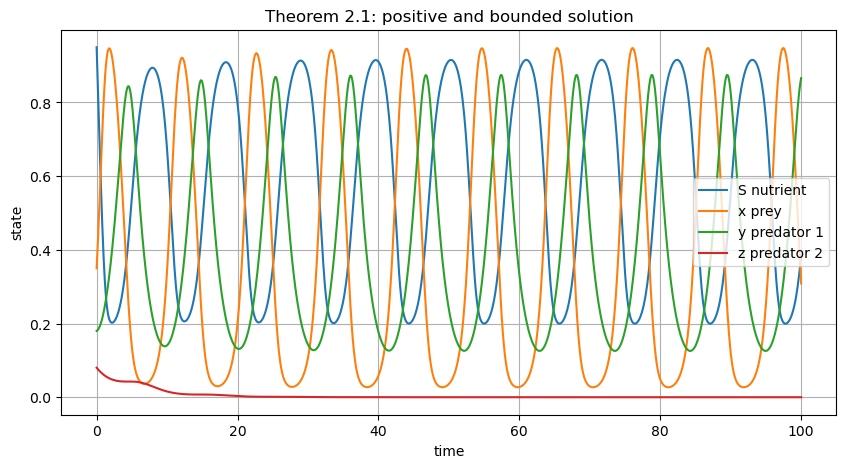

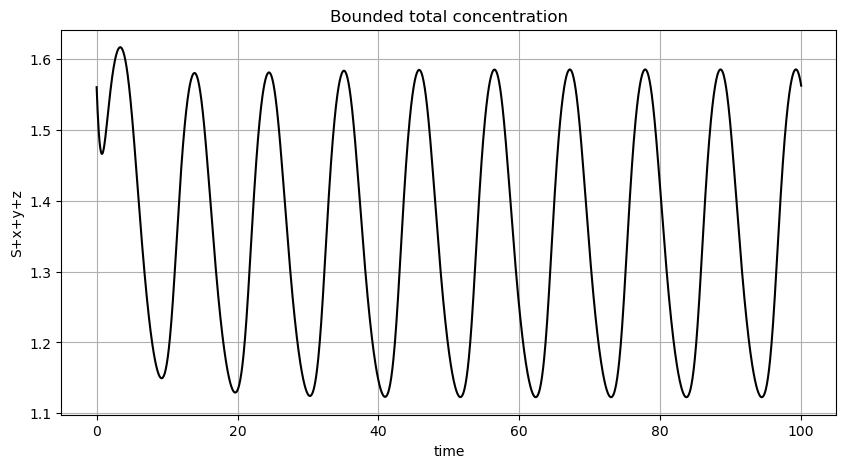

Minimum state value: 2.0157270688572827e-09


In [2]:
p_basic = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
sol = simulate(p_basic, U0=(0.95, 0.35, 0.18, 0.08), T=100)
t, S, x, y, z = plot_timeseries(sol, "Theorem 2.1: positive and bounded solution")

plt.figure()
plt.plot(t, S + x + y + z, color="black")
plt.xlabel("time")
plt.ylabel("S+x+y+z")
plt.title("Bounded total concentration")
plt.show()

print("Minimum state value:", np.min([S.min(), x.min(), y.min(), z.min()]))

## Experiment 2: washout equilibrium P0

Equivalent to Theorem 2.2. If `f1(1)<D1`, prey cannot invade even at maximum nutrient. Expected limit: `(1,0,0,0)`.

f1(1)= 0.6666666666666666 D1= 0.8


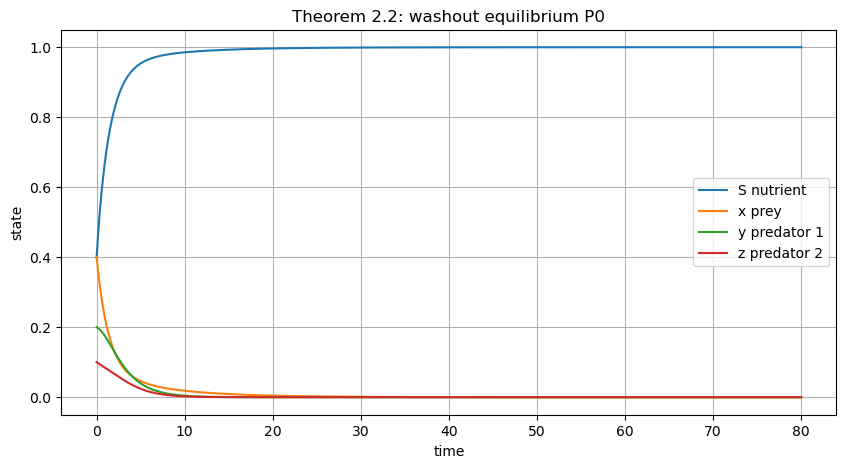

Final state: [9.99998811e-01 1.54533276e-06 3.98099253e-18 1.54420147e-18]


In [3]:
p_P0 = dict(a1=1.0, b1=0.5, a2=1.2, b2=0.4, a3=1.0, b3=0.4, D1=0.8, D2=0.5, D3=0.5)
print("f1(1)=", monod(1, p_P0["a1"], p_P0["b1"]), "D1=", p_P0["D1"])
sol = simulate(p_P0, U0=(0.4, 0.4, 0.2, 0.1), T=80)
plot_timeseries(sol, "Theorem 2.2: washout equilibrium P0")
print("Final state:", sol.y[:, -1])

## Experiment 3: boundary equilibrium P1

Equivalent to Theorem 2.4 and Theorem 3.1. Here prey survives, while both predators are washed out. We choose parameters so that `f1(1)>D1` and `f2(x1)<D2`.

P1 = (0.21538461538461537, 1.120879120879121, 0, 0)
invasion check f2(x1)-D2 = -0.03508474576271192


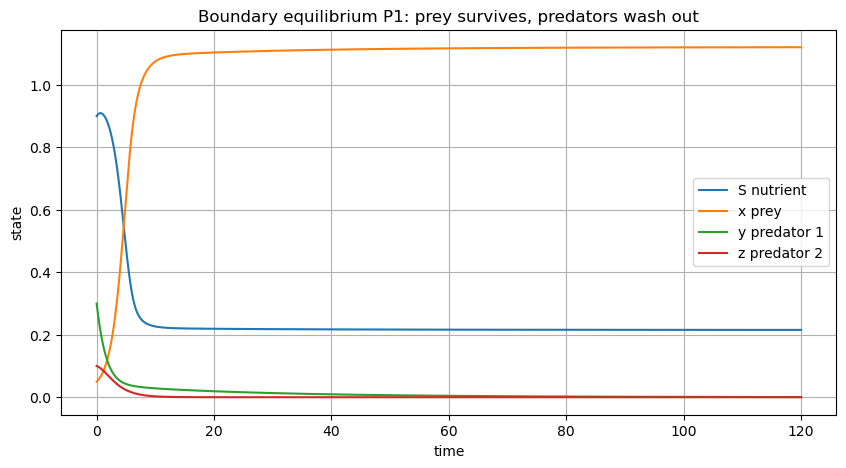

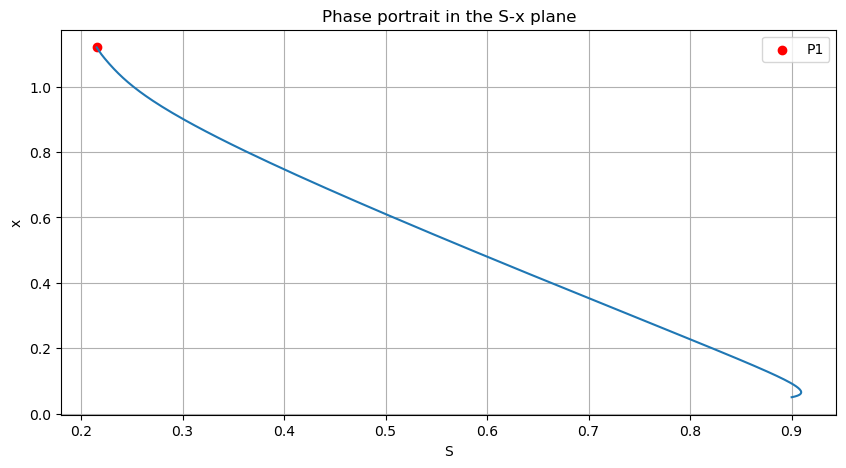

In [4]:
p_P1 = dict(a1=2.0, b1=0.4, a2=0.6, b2=0.5, a3=1.0, b3=0.4, D1=0.7, D2=0.45, D3=0.5)
S1 = monod_inv(p_P1["D1"], p_P1["a1"], p_P1["b1"])
x1 = (1 - S1) / p_P1["D1"]
print("P1 =", (S1, x1, 0, 0))
print("invasion check f2(x1)-D2 =", monod(x1, p_P1["a2"], p_P1["b2"]) - p_P1["D2"])

sol = simulate(p_P1, U0=(0.9, 0.05, 0.3, 0.1), T=120)
plot_timeseries(sol, "Boundary equilibrium P1: prey survives, predators wash out")

t = np.linspace(0, 120, 2000)
S, x, y, z = sol.sol(t)
plt.figure()
plt.plot(S, x)
plt.scatter([S1], [x1], color="red", label="P1")
plt.xlabel("S")
plt.ylabel("x")
plt.title("Phase portrait in the S-x plane")
plt.legend()
plt.show()

## Experiment 4: boundary equilibrium P2

Equivalent to Theorem 2.8 and Theorem 3.2. Nutrient, prey, and predator 1 coexist; predator 2 is washed out. We choose parameters so that `f3(y2)<D3`.

P2 = (0.6056116265125947, 0.24, 0.45731395581234413, 0)
invasion check f3(y2)-D3 = -0.11783575552345682


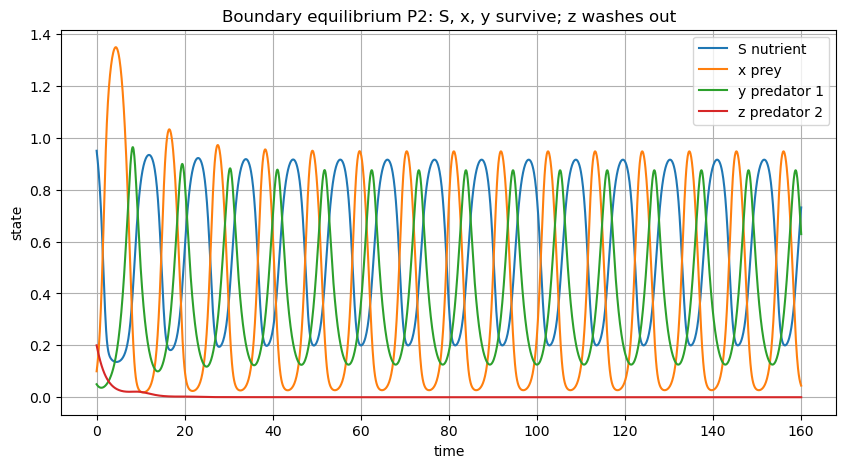

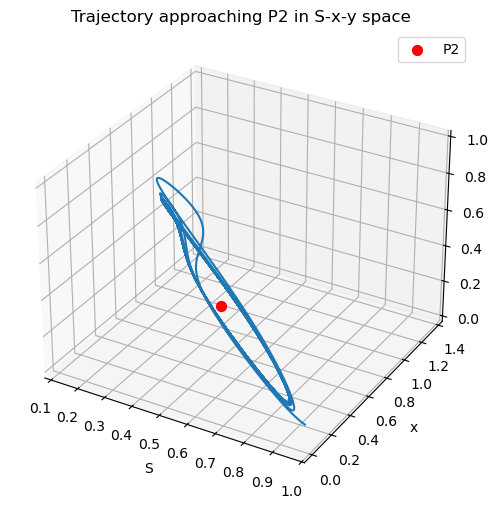

In [5]:
p_P2 = dict(a1=3.0, b1=0.5, a2=1.6, b2=0.4, a3=0.8, b3=0.5, D1=0.5, D2=0.6, D3=0.5)
x2 = monod_inv(p_P2["D2"], p_P2["a2"], p_P2["b2"])
def eq_S2(S):
    return S + monod(S, p_P2["a1"], p_P2["b1"]) * x2 - 1
S2 = brentq(eq_S2, 1e-8, 1.0)
y2 = x2 * (monod(S2, p_P2["a1"], p_P2["b1"]) - p_P2["D1"]) / p_P2["D2"]
print("P2 =", (S2, x2, y2, 0))
print("invasion check f3(y2)-D3 =", monod(y2, p_P2["a3"], p_P2["b3"]) - p_P2["D3"])

sol = simulate(p_P2, U0=(0.95, 0.1, 0.05, 0.2), T=160)
plot_timeseries(sol, "Boundary equilibrium P2: S, x, y survive; z washes out")

t = np.linspace(0, 160, 2500)
S, x, y, z = sol.sol(t)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(S, x, y)
ax.scatter([S2], [x2], [y2], color="red", s=50, label="P2")
ax.set_xlabel("S")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.set_title("Trajectory approaching P2 in S-x-y space")
ax.legend()
plt.show()